In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
import qutip as qt
from IPython.display import display, Math, Latex

# 设置全局字体为 Times New Roman
%config InlineBackend.figure_format = 'retina'
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({"font.size": 18})

# 启用 LaTeX 渲染
plt.rcParams["text.usetex"] = True

# files = sorted(glob.glob("error_*.txt"))
#  N=2 偏离直线太多了
initial = "111"
N = 5
gammas = [0.1, 1.0]
gamma_linestyles = {0.1: "-", 1.0: "--"}
scale_list = list(range(1, 10))
# coefficients for extrapolation
def caculate_coefficient(r_list):
    if r_list[-1] == 2:  # [1,2]
        b2_list = np.array([1 / 3, -4 / 3])
    elif r_list[-1] == 4 or r_list[-1] == 8:  # [1,2,4]
        b2_list = np.array([1 / 45, -4 / 9, 64 / 45])
    elif r_list[-1] == 6:  # [1,2,6]
        b2_list = np.array([1 / 105, -1 / 6, 81 / 70])
    elif r_list[-1] == 7:  # [1,2,3,7]
        b2_list = np.array([-1 / 1152, 64 / 675, -729 / 1600, 117649 / 86400])
    return b2_list

N_list = np.array([2, 3, 4, 5, 6])

r1_list = np.array([1, 2, 3, 7])
r2_list = np.array([1, 2, 4])
r3_list = np.array([1, 2, 6])

# coefficients for extrapolation
b1_list = caculate_coefficient(r1_list)
b2_list = caculate_coefficient(r2_list)
b3_list = caculate_coefficient(r3_list)

si_z = [
    qt.tensor([qt.qeye(2)] * i + [qt.sigmaz()] + [qt.qeye(2)] * (N - i - 1))
    for i in range(N)
]

O = sum([si_z[i] for i in range(N)]).full()

# record extrapolated observable values and max-r observable values for each gamma and scale
plot_data = {}

gamma_markers = {0.1: "o", 1.0: "d"}

for gamma in gammas:
    rho_superexact = np.load(
        f"../jobs/|{initial}>extrapolated/gamma_{gamma}/rho_superexact_N_{N}_no_Euler.npy"
    )
    O_superexact = np.real(np.trace(O @ rho_superexact))

    scales = []
    extrapolated_list = []
    max_r_list = []

    for scale in scale_list:
        O_list = []
        file_paths = [
            Path(f"../jobs/|{initial}>extrapolated/gamma_{gamma}/rho_N_{N}_r_{scale * r}_no_Euler.npy")
            for r in r2_list
        ]
        if not all(path.exists() for path in file_paths):
            continue

        for path in file_paths:
            rho_Trotter = np.load(path)
            O_list.append(np.real(np.trace(O @ rho_Trotter)))

        scales.append(scale)
        max_r_list.append(O_list[-1])
        extrapolated_O = sum(b * O for b, O in zip(b2_list, O_list))
        extrapolated_list.append(extrapolated_O)

    plot_data[gamma] = {
        "scales": np.asarray(scales),
        "extrapolated": np.asarray(extrapolated_list),
        "max_r": np.asarray(max_r_list),
        "superexact": O_superexact,
    }

    print(f"gamma={gamma}: available scales = {scales}")
    print("Extrapolated values:", extrapolated_list)
    print("Max r values:", max_r_list)

gamma=0.1: available scales = [1, 2, 3, 4, 5, 6, 7, 8, 9]
Extrapolated values: [np.float64(-1.9657396427147926), np.float64(-1.8137906753484967), np.float64(-1.8239312778079553), np.float64(-1.8242638718009985), np.float64(-1.8243049204574509), np.float64(-1.8243135550133023), np.float64(-1.8243160187132832), np.float64(-1.8243168771891891), np.float64(-1.8243172220473372)]
Max r values: [np.float64(-2.034044836584008), np.float64(-1.877522399608081), np.float64(-1.8479801806467948), np.float64(-1.8376293341659773), np.float64(-1.83283738142145), np.float64(-1.8302341774063917), np.float64(-1.8286644863959187), np.float64(-1.8276456837066402), np.float64(-1.8269471911396904)]
gamma=1.0: available scales = [1, 2, 3, 4, 5, 6, 7, 8, 9]
Extrapolated values: [np.float64(3.2662062239375453), np.float64(3.235473726168822), np.float64(3.2374525062858637), np.float64(3.2375433426083218), np.float64(3.237550902160541), np.float64(3.2375517867689725), np.float64(3.2375520863324274), np.float64(3.

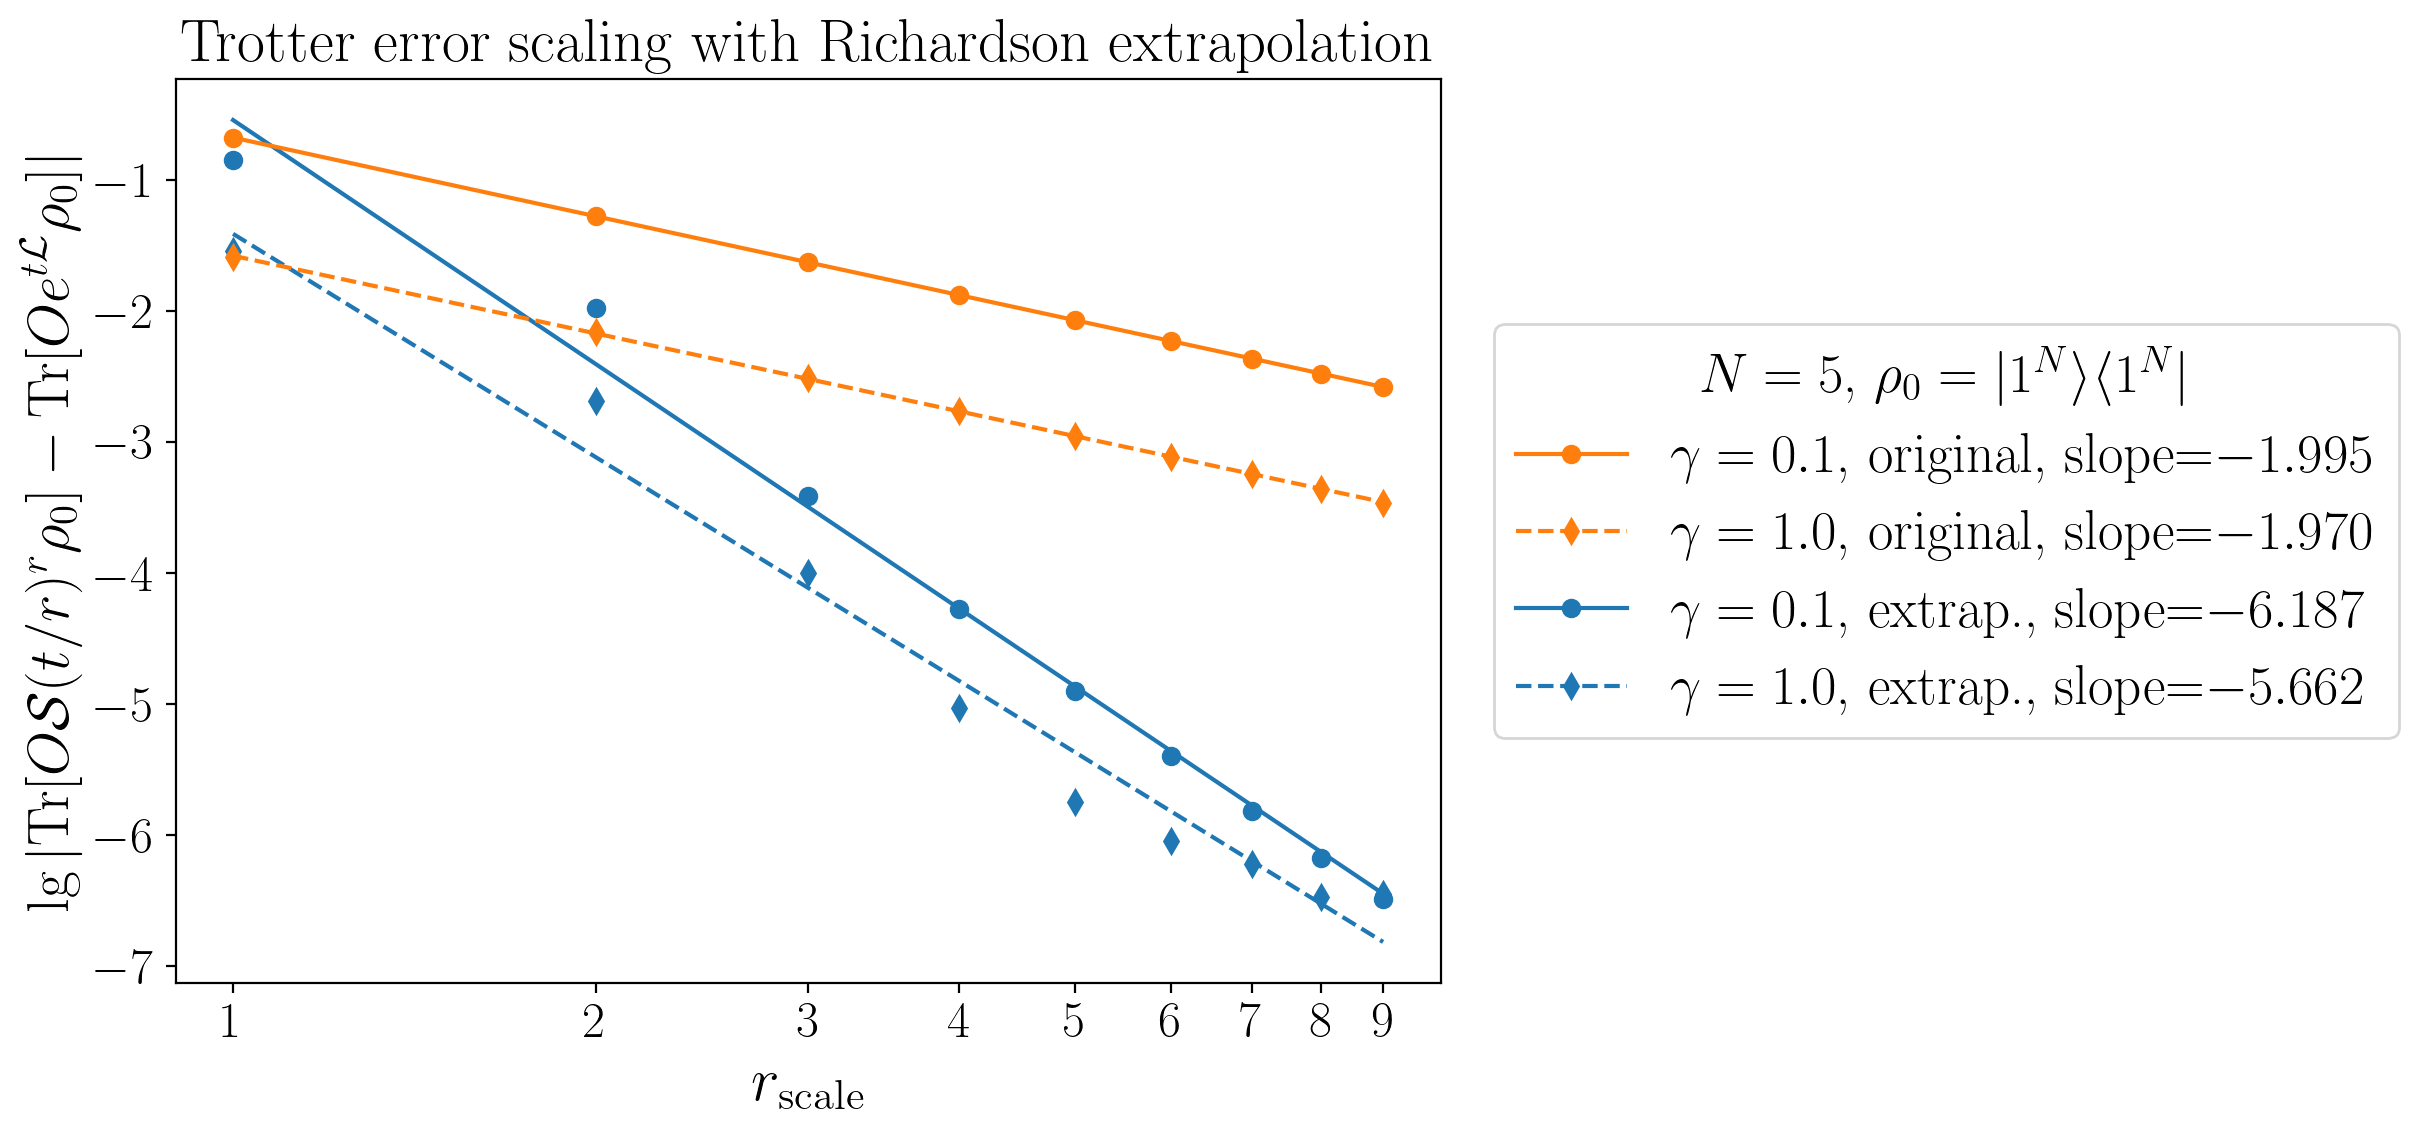

In [21]:
fig, ax = plt.subplots(figsize=(12.5, 6))
handles = []

for gamma in gammas:
    scales = plot_data[gamma]["scales"]
    extrapolated_arr = plot_data[gamma]["extrapolated"]
    max_r_arr = plot_data[gamma]["max_r"]
    O_superexact = plot_data[gamma]["superexact"]
    linestyle = gamma_linestyles[gamma]

    marker = gamma_markers[gamma]

    x = np.log10(scales)
    y_extrapolated = np.log10(np.abs(extrapolated_arr - O_superexact))
    y_max_r = np.log10(np.abs(max_r_arr - O_superexact))
    x_fit = np.linspace(x.min(), x.max(), 200)

    k_extrapolated, b_extrapolated = np.polyfit(x, y_extrapolated, 1)
    k_max_r, b_max_r = np.polyfit(x, y_max_r, 1)

    ax.plot(
        x,
        y_extrapolated,
        color="C0",
        marker=marker,
        linestyle="None",
    )
    ax.plot(
        x_fit,
        k_extrapolated * x_fit + b_extrapolated,
        color="C0",
        linestyle=linestyle,
    )
    handles.append(
        Line2D(
            [0],
            [0],
            color="C0",
            linestyle=linestyle,
            marker=marker,
            markersize=6,
            label=rf"$\gamma={gamma}$, extrap., slope=${k_extrapolated:.3f}$",
        )
    )

    ax.plot(
        x,
        y_max_r,
        color="C1",
        marker=marker,
        linestyle="None",
    )
    ax.plot(
        x_fit,
        k_max_r * x_fit + b_max_r,
        color="C1",
        linestyle=linestyle,
    )
    handles.append(
        Line2D(
            [0], [0],
            color="C1",
            linestyle=linestyle,
            marker=marker,
            markersize=6,
            label=rf"$\gamma={gamma}$, original, slope=${k_max_r:.3f}$",
        )
    )

# Richardson extrapolation
# Largest-r baseline

ax.set_xlabel("$r_{\mathrm{scale}}$", fontsize=22)
ax.set_ylabel(
    "$\lg|\mathrm{Tr}[O\mathcal{S}(t/r)^r\\rho_0]-\mathrm{Tr}[Oe^{t\mathcal{L}}\\rho_0]|$",
    fontsize=21,
)

ax.set_xticks(np.log10(scale_list))
ax.set_xticklabels(scale_list)
# ax.set_xticklabels(range(2, 12))
# ax.set_yticks(np.arange(-22, 0, 4))
legend_order = [1, 3, 0, 2]
ax.legend(
    title=f'$N={N}$, $\\rho_0=|1^N\\rangle\langle1^N|$', 
    title_fontsize=20,
    handles=[handles[i] for i in legend_order],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=20,
)
ax.set_title("Trotter error scaling with Richardson extrapolation", fontsize=22) #, y=1.02)
fig.tight_layout()
plt.savefig(f"extrapolation-{N}-{initial}_scaling.pdf")
plt.show()